# Multi-Fidelity Autoencoder

This notebook studies the reconstruction performance of the multi-fidelity autoencoder on the synthetic benchmark defined previously. The goal is to assess how well the model compresses and reconstructs low-fidelity and high-fidelity states, and how its performance changes with different training configurations and amounts of data.

The autoencoder is built around a shared latent representation. In the current formulation:
- low-fidelity and high-fidelity snapshots are passed through fidelity-specific input modules,
- then mapped into a common latent space,
- and finally decoded through fidelity-specific output modules.

Schematically, the model has the form
$$
x^{(f)} \xrightarrow{\;\mathcal E^{(f)}\;} z \xrightarrow{\;\mathcal D^{(f)}\;} \hat{x}^{(f)},
\qquad f \in \{\mathrm{LF},\mathrm{HF}\},
$$
where:
- $x^{(f)}$ is the input state at fidelity $f$,
- $\mathcal E^{(f)}$ is the encoder for fidelity $f$,
- $z$ is the shared latent representation,
- $\mathcal D^{(f)}$ is the decoder for fidelity $f$,
- $\hat{x}^{(f)}$ is the reconstructed state.

The training procedure can combine different loss terms.

A standard reconstruction term is
$$
\mathcal L_{\mathrm{rec}}^{(f)}
=
\frac{1}{N_f}
\sum_{i=1}^{N_f}
\left\|
x_i^{(f)} - \hat{x}_i^{(f)}
\right\|^2,
\qquad f \in \{\mathrm{LF},\mathrm{HF}\}.
$$

For paired low- and high-fidelity states, a shared-latent alignment term can also be introduced:
$$
\mathcal L_{\mathrm{align}}
=
\frac{1}{N_{\mathrm{MF}}}
\sum_{i=1}^{N_{\mathrm{MF}}}
\left\|
z_i^{(\mathrm{LF})} - z_i^{(\mathrm{HF})}
\right\|^2.
$$

If latent dynamics regularization is used, one may also include a SINDy residual term of the form
$$
\mathcal L_{\mathrm{SINDy}}
=
\frac{1}{N}
\sum_{i=1}^{N}
\left\|
\dot z_i - \Theta(z_i)\,\Xi
\right\|^2,
$$
where $\Theta(z)$ is the chosen library of candidate functions and $\Xi$ is the matrix of SINDy coefficients.

A typical total objective is therefore
$$
\mathcal L
=
\lambda_{\mathrm{LF}} \mathcal L_{\mathrm{rec}}^{(\mathrm{LF})}
+
\lambda_{\mathrm{HF}} \mathcal L_{\mathrm{rec}}^{(\mathrm{HF})}
+
\lambda_{\mathrm{align}} \mathcal L_{\mathrm{align}}
+
\lambda_{\mathrm{SINDy}} \mathcal L_{\mathrm{SINDy}}.
$$

In this notebook, we use a train/validation split, emphasize high-fidelity reconstruction slightly more strongly than low-fidelity reconstruction, and inspect both reconstructions and learned latent trajectories.


In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch

from mfl_rom.benchmarks.synthetic.spiral_ode import (
    generate_mf_trajectory,
    generate_trajectory,
    sample_ic,
)
from mfl_rom.compression import NTKLossWeights, ensure_loss_weight_strategy
from mfl_rom.compression.training import (
    BatchSizes,
    extract_shared_latent,
    fit,
    paired_common_time_grid,
    resample_state_sequence,
    sindy_residual_term,
    snapshot_reconstruction_term,
    state_alignment_term,
)
from mfl_rom.data import TrainingTrajectoryDataset

torch.set_default_dtype(torch.float32)

rng = np.random.default_rng(0)
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print(f"Using device: {device}")


Using device: cpu


## Dataset

We build a small synthetic training and validation dataset. The paired multi-fidelity samples provide both LF and HF trajectories, while the extra single-fidelity pool is used only for LF. This keeps the notebook simple while still exercising the full multifidelity training pipeline.


In [2]:
def split_train_val(items, n_val):
    if n_val == 0:
        return items, []
    return items[:-n_val], items[-n_val:]


n_mf_total = 32
n_lf_total = 96

n_mf_val = 4
n_lf_val = 4

lf_time = np.linspace(0.0, 10.0, 100)
hf_time = np.linspace(0.0, 10.0, 1000)

mf_all = [
    generate_mf_trajectory(
        ic=sample_ic(rng=rng),
        lf_time=lf_time,
        hf_time=hf_time,
        rng=rng,
    )
    for _ in range(n_mf_total)
]

lf_all = [
    generate_trajectory(
        ic=sample_ic(rng=rng),
        time=lf_time,
        fidelity="LF",
        rng=rng,
    )
    for _ in range(n_lf_total)
]

mf_train, mf_val = split_train_val(mf_all, n_mf_val)
lf_train, lf_val = split_train_val(lf_all, n_lf_val)

train_dataset = TrainingTrajectoryDataset(
    mf_samples=mf_train,
    lf_samples=lf_train,
    hf_samples=[],
)

val_dataset = TrainingTrajectoryDataset(
    mf_samples=mf_val,
    lf_samples=lf_val,
    hf_samples=[],
)

example_mf = train_dataset.mf_samples[0]

print(f"Train MF samples: {len(train_dataset.mf_samples)}")
print(f"Train LF-only samples: {len(train_dataset.lf_samples)}")
print(f"Train HF-only samples: {len(train_dataset.hf_samples)}")
print()
print(f"Val MF samples: {len(val_dataset.mf_samples)}")
print(f"Val LF-only samples: {len(val_dataset.lf_samples)}")
print(f"Val HF-only samples: {len(val_dataset.hf_samples)}")
print()
print("LF paired shape:", example_mf.lf_trajectory.states.shape)
print("HF paired shape:", example_mf.hf_trajectory.states.shape)


Train MF samples: 28
Train LF-only samples: 92
Train HF-only samples: 0

Val MF samples: 4
Val LF-only samples: 4
Val HF-only samples: 0

LF paired shape: (100, 16, 16)
HF paired shape: (1000, 32, 32)


## Inspection

We first inspect one paired sample from the training set to confirm that the LF and HF observations are coherent and that the expected resolution gap is visible.


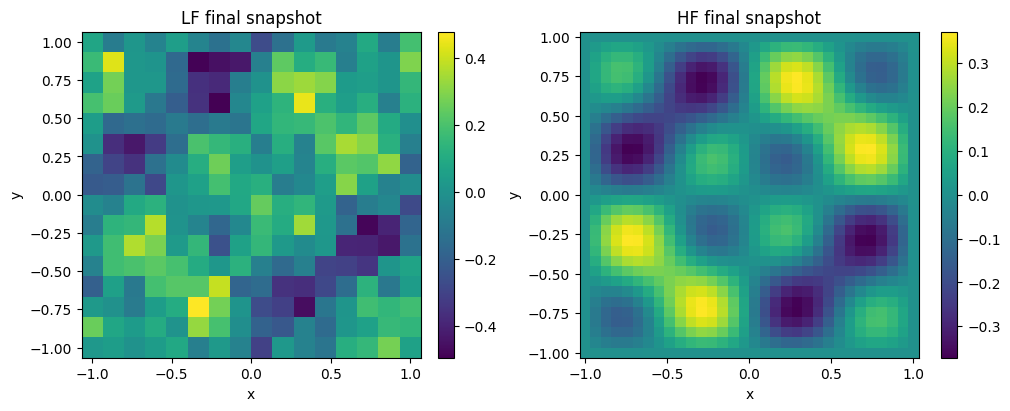

In [3]:
example_mf = train_dataset.mf_samples[0]

lf_snapshot = example_mf.lf_trajectory.states[-1]
hf_snapshot = example_mf.hf_trajectory.states[-1]

x_lf = np.linspace(-1.0, 1.0, lf_snapshot.shape[0])
y_lf = np.linspace(-1.0, 1.0, lf_snapshot.shape[1])
x_hf = np.linspace(-1.0, 1.0, hf_snapshot.shape[0])
y_hf = np.linspace(-1.0, 1.0, hf_snapshot.shape[1])

X_lf, Y_lf = np.meshgrid(x_lf, y_lf, indexing="ij")
X_hf, Y_hf = np.meshgrid(x_hf, y_hf, indexing="ij")

fig, ax = plt.subplots(1, 2, figsize=(10, 4), constrained_layout=True)

pcm0 = ax[0].pcolormesh(X_lf, Y_lf, lf_snapshot, shading="auto")
ax[0].set_title("LF final snapshot")
ax[0].set_xlabel("x")
ax[0].set_ylabel("y")
fig.colorbar(pcm0, ax=ax[0])

pcm1 = ax[1].pcolormesh(X_hf, Y_hf, hf_snapshot, shading="auto")
ax[1].set_title("HF final snapshot")
ax[1].set_xlabel("x")
ax[1].set_ylabel("y")
fig.colorbar(pcm1, ax=ax[1])

plt.show()


## Autoencoder

Here we construct a simple shared-latent autoencoder for the synthetic multi-fidelity dataset.

The model takes as input a snapshot $x^{(f)}$ at fidelity $f \in \{\mathrm{LF}, \mathrm{HF}\}$, encodes it into a common latent representation $z$, and reconstructs it back to the same fidelity:
$$
x^{(f)} \xrightarrow{\;\mathcal E^{(f)}\;} z \xrightarrow{\;\mathcal D^{(f)}\;} \hat{x}^{(f)}.
$$

The implementation is modular. The autoencoder is assembled from:
- fidelity-specific encoder stems,
- a shared encoder trunk,
- a latent projection,
- a latent expansion,
- a shared decoder trunk,
- fidelity-specific decoder heads.

In this notebook we use a simple fully connected architecture:
- each input field is flattened,
- mapped to a common hidden dimension,
- compressed into a low-dimensional latent space,
- and then reconstructed back to the original LF or HF field shape.

This is intentionally a minimal model. Its role is not to be the final architecture, but to provide a clean first test of:
- the shared-latent autoencoder interface,
- the multi-fidelity training utilities,
- and the reconstruction/alignment pipeline on the synthetic benchmark.


In [4]:
import torch.nn as nn

from mfl_rom.compression.shared import SharedLatentAutoencoder

lf_shape = example_mf.lf_trajectory.states.shape[1:]
hf_shape = example_mf.hf_trajectory.states.shape[1:]

lf_dim = int(np.prod(lf_shape))
hf_dim = int(np.prod(hf_shape))

stem_dim = 64
trunk_dim = 32
latent_dim = 2

model = SharedLatentAutoencoder(
    encoder_stems={
        "LF": nn.Sequential(
            nn.Flatten(),
            nn.Linear(lf_dim, stem_dim),
            nn.ReLU(),
        ),
        "HF": nn.Sequential(
            nn.Flatten(),
            nn.Linear(hf_dim, stem_dim),
            nn.ReLU(),
        ),
    },
    shared_encoder=nn.Sequential(
        nn.Linear(stem_dim, trunk_dim),
        nn.ReLU(),
    ),
    to_latent=nn.Linear(trunk_dim, latent_dim),
    from_latent=nn.Linear(latent_dim, trunk_dim),
    shared_decoder=nn.Sequential(
        nn.Linear(trunk_dim, stem_dim),
        nn.ReLU(),
    ),
    decoder_heads={
        "LF": nn.Sequential(
            nn.Linear(stem_dim, lf_dim),
            nn.Unflatten(1, lf_shape),
        ),
        "HF": nn.Sequential(
            nn.Linear(stem_dim, hf_dim),
            nn.Unflatten(1, hf_shape),
        ),
    },
    latent_dim=latent_dim,
).to(device)

num_parameters = sum(p.numel() for p in model.parameters() if p.requires_grad)

print(model)
print(f"Trainable parameters: {num_parameters:,}")


SharedLatentAutoencoder(
  (encoder_stems): ModuleDict(
    (LF): Sequential(
      (0): Flatten(start_dim=1, end_dim=-1)
      (1): Linear(in_features=256, out_features=64, bias=True)
      (2): ReLU()
    )
    (HF): Sequential(
      (0): Flatten(start_dim=1, end_dim=-1)
      (1): Linear(in_features=1024, out_features=64, bias=True)
      (2): ReLU()
    )
  )
  (shared_encoder): Sequential(
    (0): Linear(in_features=64, out_features=32, bias=True)
    (1): ReLU()
  )
  (to_latent): Linear(in_features=32, out_features=2, bias=True)
  (from_latent): Linear(in_features=2, out_features=32, bias=True)
  (shared_decoder): Sequential(
    (0): Linear(in_features=32, out_features=64, bias=True)
    (1): ReLU()
  )
  (decoder_heads): ModuleDict(
    (LF): Sequential(
      (0): Linear(in_features=64, out_features=256, bias=True)
      (1): Unflatten(dim=1, unflattened_size=(16, 16))
    )
    (HF): Sequential(
      (0): Linear(in_features=64, out_features=1024, bias=True)
      (1): Unf

## Training Setup

The training objective combines four SGD-compatible terms:
- LF reconstruction on independent LF snapshots,
- HF reconstruction on independent HF snapshots,
- paired state alignment in the shared latent space,
- a shared SINDy residual term on paired temporal transitions.

In this notebook we use NTK-inspired adaptive weights as the default training strategy. The adaptive coefficients are initialized from a set of base weights, then updated from the gradient norms of the shared trainable parameters during training.


In [5]:
from math import comb

base_weight_values = {
    "lf_reconstruction": 0.01,
    "hf_reconstruction": 1.0,
    "state_alignment": 0.1,
    "sindy_residual": 1.0e-3,
}

loss_weights = NTKLossWeights(
    base_weight_values,
    ema_decay=0.9,
    power=1.0,
    update_interval=1,
    min_weight=1.0e-6,
)


def sindy_library(
    z: torch.Tensor,
    degree: int = 3,
    include_bias: bool = False,
) -> torch.Tensor:
    terms = []

    if include_bias:
        terms.append(torch.ones((z.shape[0], 1), device=z.device, dtype=z.dtype))

    latent_dimension = z.shape[1]

    if degree >= 1:
        terms.extend(z[:, i : i + 1] for i in range(latent_dimension))

    if degree >= 2:
        terms.extend(
            z[:, i : i + 1] * z[:, j : j + 1]
            for i in range(latent_dimension)
            for j in range(i, latent_dimension)
        )

    if degree >= 3:
        terms.extend(
            z[:, i : i + 1] * z[:, j : j + 1] * z[:, k : k + 1]
            for i in range(latent_dimension)
            for j in range(i, latent_dimension)
            for k in range(j, latent_dimension)
        )

    return torch.cat(terms, dim=1)


def num_polynomial_library_terms(
    latent_dimension: int,
    degree: int,
    include_bias: bool = False,
) -> int:
    num_terms = comb(latent_dimension + degree, degree)
    if not include_bias:
        num_terms -= 1
    return num_terms


num_library_terms = num_polynomial_library_terms(
    latent_dimension=latent_dim,
    degree=3,
    include_bias=False,
)

coefficients = nn.Parameter(
    1.0e-3 * torch.randn(num_library_terms, latent_dim, device=device)
)

optimizer = torch.optim.Adam(
    list(model.parameters()) + [coefficients],
    weight_decay=1e-12,
    lr=1.0e-3,
)

scheduler = torch.optim.lr_scheduler.StepLR(
    optimizer,
    step_size=20,
    gamma=0.5,
)

batch_sizes = BatchSizes(
    lf=1024,
    hf=1024,
    mf_state=1024,
    mf_sindy=1024,
)


def loss_fn(model, batch_kind, batch, device):
    if batch_kind == "lf":
        rec = snapshot_reconstruction_term(model, batch, "LF", device)
        loss_weights.update(name="lf_reconstruction", loss=rec, model=model)
        loss = loss_weights["lf_reconstruction"] * rec
        return loss, {
            "loss": float(loss.detach().cpu()),
            "reconstruction": float(rec.detach().cpu()),
        }

    if batch_kind == "hf":
        rec = snapshot_reconstruction_term(model, batch, "HF", device)
        loss_weights.update(name="hf_reconstruction", loss=rec, model=model)
        loss = loss_weights["hf_reconstruction"] * rec
        return loss, {
            "loss": float(loss.detach().cpu()),
            "reconstruction": float(rec.detach().cpu()),
        }

    if batch_kind == "mf_state":
        align = state_alignment_term(model, batch, device)
        loss_weights.update(name="state_alignment", loss=align, model=model)
        loss = loss_weights["state_alignment"] * align
        return loss, {
            "loss": float(loss.detach().cpu()),
            "state_alignment": float(align.detach().cpu()),
        }

    if batch_kind == "mf_sindy":
        sindy = sindy_residual_term(
            model=model,
            batch=batch,
            device=device,
            coefficients=coefficients,
            library_fn=sindy_library,
        )
        loss_weights.update(name="sindy_residual", loss=sindy, model=model)
        loss = loss_weights["sindy_residual"] * sindy
        return loss, {
            "loss": float(loss.detach().cpu()),
            "sindy_residual": float(sindy.detach().cpu()),
        }

    raise ValueError(f"Unknown batch kind: {batch_kind}")


print("Base weights:", base_weight_values)
print("Initial adaptive weights:", loss_weights.as_dict())
print("Number of SINDy library terms:", num_library_terms)
print("Coefficient matrix shape:", tuple(coefficients.shape))
print("Batch sizes:", batch_sizes)


Base weights: {'lf_reconstruction': 0.01, 'hf_reconstruction': 1.0, 'state_alignment': 0.1, 'sindy_residual': 0.001}
Initial adaptive weights: {'lf_reconstruction': 0.01, 'hf_reconstruction': 1.0, 'state_alignment': 0.1, 'sindy_residual': 0.001}
Number of SINDy library terms: 9
Coefficient matrix shape: (9, 2)
Batch sizes: BatchSizes(lf=1024, hf=1024, mf_state=1024, mf_sindy=1024)


## Training History

We train on the training split and monitor the same metrics on the validation split. This gives a first view of whether the optimization is stable and whether the NTK-inspired weighting yields a reasonable balance between the competing objectives.


  0%|          | 1/200 [00:02<09:05,  2.74s/it]

Epoch    1/200: train_lf/loss=1.1587e-02 | train_hf/loss=4.0031e-02 | train_mf_state/loss=1.1684e-04 | train_mf_sindy/loss=1.1253e-06 | val_lf/loss=1.6313e-04 | val_hf/loss=4.7490e-02 | val_mf_state/loss=9.8990e-06 | val_mf_sindy/loss=1.3819e-06


  1%|          | 2/200 [00:49<1:34:06, 28.52s/it]

Epoch    2/200: train_lf/loss=1.7878e-04 | train_hf/loss=1.5360e-02 | train_mf_state/loss=1.8723e-04 | train_mf_sindy/loss=4.7234e-06 | val_lf/loss=5.4742e-04 | val_hf/loss=1.5068e-02 | val_mf_state/loss=6.2459e-05 | val_mf_sindy/loss=3.7498e-06


  2%|▏         | 3/200 [00:51<54:54, 16.72s/it]  

...

Epoch  198/200: train_lf/loss=2.5832e-06 | train_hf/loss=3.3235e-07 | train_mf_state/loss=6.4152e-07 | train_mf_sindy/loss=6.9634e-08 | val_lf/loss=2.7190e-06 | val_hf/loss=5.1237e-06 | val_mf_state/loss=1.2795e-06 | val_mf_sindy/loss=1.1679e-07


100%|█████████▉| 199/200 [43:40<00:03,  3.64s/it]

Epoch  199/200: train_lf/loss=2.6782e-06 | train_hf/loss=3.2574e-07 | train_mf_state/loss=5.3764e-07 | train_mf_sindy/loss=6.9722e-08 | val_lf/loss=2.2926e-06 | val_hf/loss=5.1573e-06 | val_mf_state/loss=1.1957e-06 | val_mf_sindy/loss=1.1673e-07


100%|██████████| 200/200 [43:43<00:00, 13.12s/it]

Epoch  200/200: train_lf/loss=2.3055e-06 | train_hf/loss=3.3931e-07 | train_mf_state/loss=7.0975e-07 | train_mf_sindy/loss=6.9579e-08 | val_lf/loss=2.9577e-06 | val_hf/loss=5.1280e-06 | val_mf_state/loss=1.4524e-06 | val_mf_sindy/loss=1.1675e-07


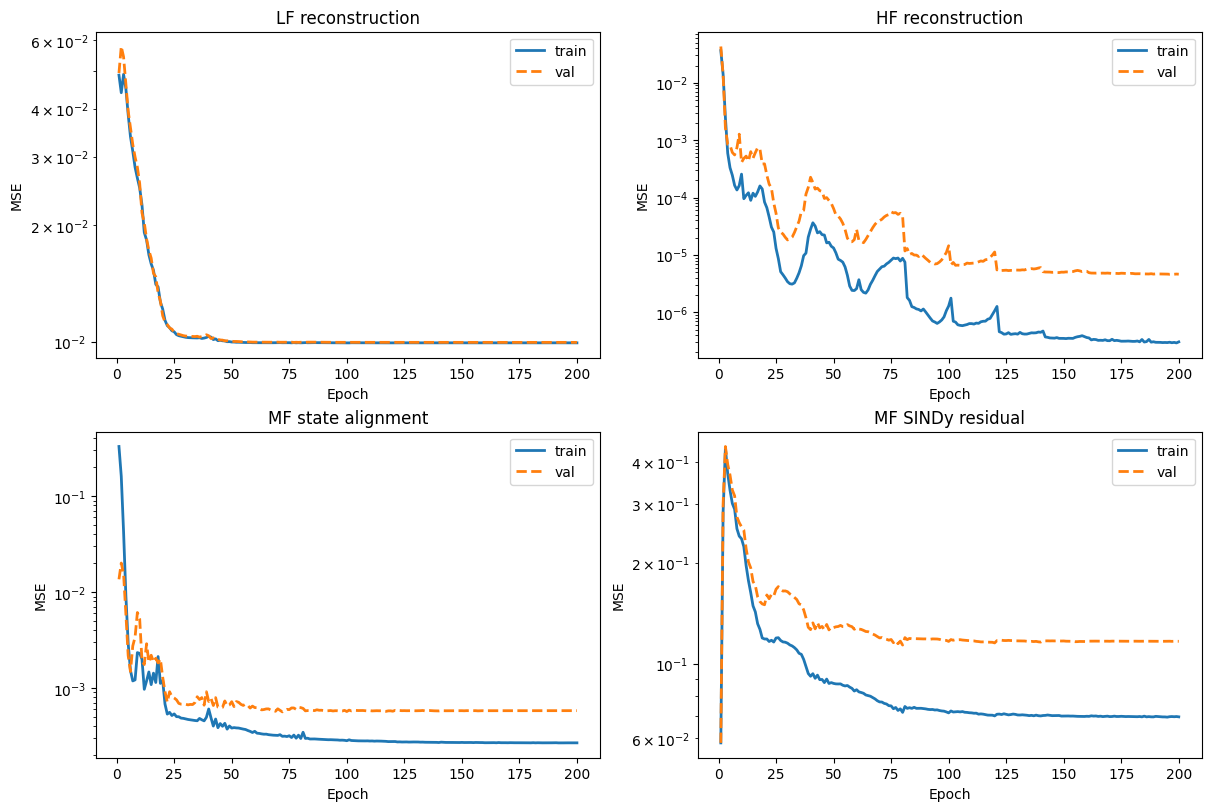

Final adaptive weights: {'lf_reconstruction': 0.00029652821123923574, 'hf_reconstruction': 1.1082074259386347, 'state_alignment': 0.0024958819840687737, 'sindy_residual': 1e-06}
Gradient-norm EMA: {'lf_reconstruction': 0.002289239898229958, 'hf_reconstruction': 6.125425488456007e-05, 'state_alignment': 0.0027197768824788102, 'sindy_residual': 0.41425553515092994}


In [6]:
num_epochs = 200

history = fit(
    model=model,
    dataset=train_dataset,
    optimizer=optimizer,
    device=device,
    loss_fn=loss_fn,
    num_epochs=num_epochs,
    batch_sizes=batch_sizes,
    val_dataset=val_dataset,
    scheduler=scheduler,
    rng=rng,
)

epochs = np.arange(1, len(history) + 1)

metric_specs = [
    ("LF reconstruction", "lf/reconstruction"),
    ("HF reconstruction", "hf/reconstruction"),
    ("MF state alignment", "mf_state/state_alignment"),
    ("MF SINDy residual", "mf_sindy/sindy_residual"),
]

fig, ax = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)

for axis, (title, suffix) in zip(ax.ravel(), metric_specs, strict=True):
    train_values = [row.get(f"train_{suffix}", np.nan) for row in history]
    val_values = [row.get(f"val_{suffix}", np.nan) for row in history]

    axis.plot(epochs, train_values, linewidth=2, label="train")
    axis.plot(epochs, val_values, linewidth=2, linestyle="--", label="val")
    axis.set_title(title)
    axis.set_xlabel("Epoch")
    axis.set_ylabel("MSE")
    axis.set_yscale("log")
    axis.legend()

plt.show()

print("Final adaptive weights:", loss_weights.as_dict())
print("Gradient-norm EMA:", loss_weights.grad_norm_ema)


## Reconstructions

We inspect one paired sample from the validation set and compare the true LF/HF states with their reconstructions. This is the most direct qualitative check of the learned representation.


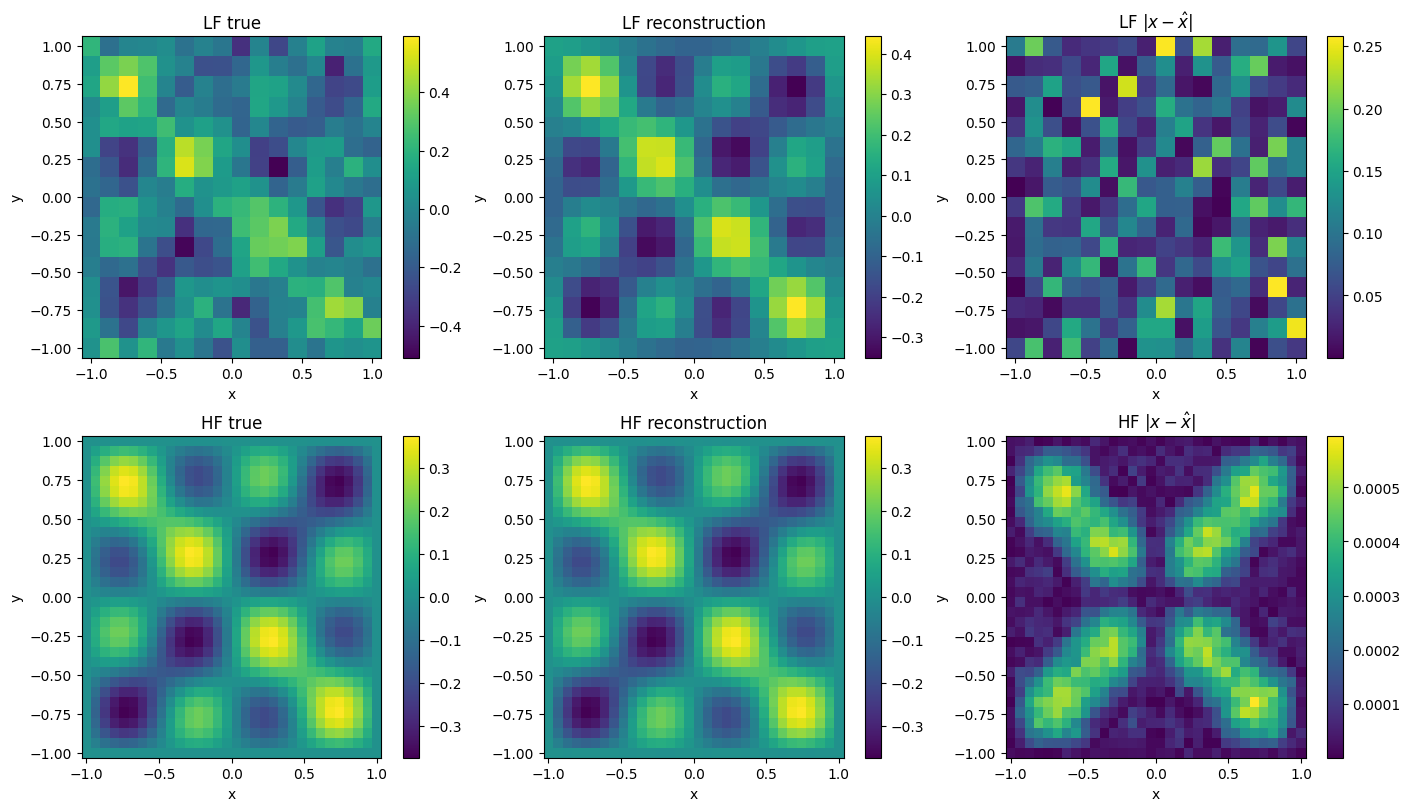

In [7]:
model.eval()

inspection_dataset = val_dataset if len(val_dataset.mf_samples) > 0 else train_dataset
example_mf = inspection_dataset.mf_samples[0]

lf_input = torch.as_tensor(
    example_mf.lf_trajectory.states,
    dtype=torch.float32,
    device=device,
)
hf_input = torch.as_tensor(
    example_mf.hf_trajectory.states,
    dtype=torch.float32,
    device=device,
)

with torch.no_grad():
    lf_reconstruction = model.reconstruct(lf_input, "LF").cpu().numpy()
    hf_reconstruction = model.reconstruct(hf_input, "HF").cpu().numpy()

lf_true = example_mf.lf_trajectory.states[-1]
lf_pred = lf_reconstruction[-1]
lf_error = np.abs(lf_true - lf_pred)

hf_true = example_mf.hf_trajectory.states[-1]
hf_pred = hf_reconstruction[-1]
hf_error = np.abs(hf_true - hf_pred)

x_lf = np.linspace(-1.0, 1.0, lf_true.shape[0])
y_lf = np.linspace(-1.0, 1.0, lf_true.shape[1])
x_hf = np.linspace(-1.0, 1.0, hf_true.shape[0])
y_hf = np.linspace(-1.0, 1.0, hf_true.shape[1])

X_lf, Y_lf = np.meshgrid(x_lf, y_lf, indexing="ij")
X_hf, Y_hf = np.meshgrid(x_hf, y_hf, indexing="ij")

fig, ax = plt.subplots(2, 3, figsize=(14, 8), constrained_layout=True)

pcm = ax[0, 0].pcolormesh(X_lf, Y_lf, lf_true, shading="auto")
ax[0, 0].set_title("LF true")
fig.colorbar(pcm, ax=ax[0, 0])

pcm = ax[0, 1].pcolormesh(X_lf, Y_lf, lf_pred, shading="auto")
ax[0, 1].set_title("LF reconstruction")
fig.colorbar(pcm, ax=ax[0, 1])

pcm = ax[0, 2].pcolormesh(X_lf, Y_lf, lf_error, shading="auto")
ax[0, 2].set_title(r"LF $|x-\hat{x}|$")
fig.colorbar(pcm, ax=ax[0, 2])

pcm = ax[1, 0].pcolormesh(X_hf, Y_hf, hf_true, shading="auto")
ax[1, 0].set_title("HF true")
fig.colorbar(pcm, ax=ax[1, 0])

pcm = ax[1, 1].pcolormesh(X_hf, Y_hf, hf_pred, shading="auto")
ax[1, 1].set_title("HF reconstruction")
fig.colorbar(pcm, ax=ax[1, 1])

pcm = ax[1, 2].pcolormesh(X_hf, Y_hf, hf_error, shading="auto")
ax[1, 2].set_title(r"HF $|x-\hat{x}|$")
fig.colorbar(pcm, ax=ax[1, 2])

for axis in ax.ravel():
    axis.set_xlabel("x")
    axis.set_ylabel("y")

plt.show()


## Latent Trajectories

Finally, we resample one paired LF/HF sample onto a common physical time grid and inspect the encoded latent trajectories. This gives a direct view of how closely the shared latent space aligns the two fidelities.


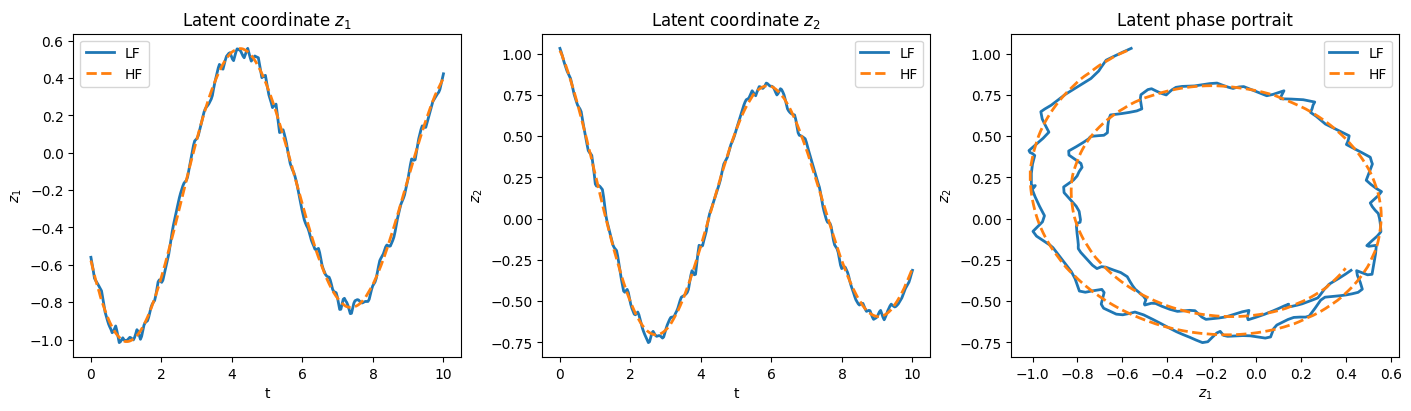

In [8]:
comparison_sample = (
    val_dataset.mf_samples[0]
    if len(val_dataset.mf_samples) > 0
    else train_dataset.mf_samples[0]
)

common_time = paired_common_time_grid(comparison_sample, target_steps=300)

lf_states = resample_state_sequence(
    comparison_sample.lf_trajectory.time,
    comparison_sample.lf_trajectory.states,
    common_time,
)
hf_states = resample_state_sequence(
    comparison_sample.hf_trajectory.time,
    comparison_sample.hf_trajectory.states,
    common_time,
)

lf_tensor = torch.as_tensor(lf_states, dtype=torch.float32, device=device)
hf_tensor = torch.as_tensor(hf_states, dtype=torch.float32, device=device)

with torch.no_grad():
    z_lf = extract_shared_latent(model, model.encode(lf_tensor, "LF")).cpu().numpy()
    z_hf = extract_shared_latent(model, model.encode(hf_tensor, "HF")).cpu().numpy()

fig, ax = plt.subplots(1, 3, figsize=(14, 4), constrained_layout=True)

ax[0].plot(common_time, z_lf[:, 0], linewidth=2, label="LF")
ax[0].plot(common_time, z_hf[:, 0], linewidth=2, linestyle="--", label="HF")
ax[0].set_title(r"Latent coordinate $z_1$")
ax[0].set_xlabel("t")
ax[0].set_ylabel(r"$z_1$")
ax[0].legend()

ax[1].plot(common_time, z_lf[:, 1], linewidth=2, label="LF")
ax[1].plot(common_time, z_hf[:, 1], linewidth=2, linestyle="--", label="HF")
ax[1].set_title(r"Latent coordinate $z_2$")
ax[1].set_xlabel("t")
ax[1].set_ylabel(r"$z_2$")
ax[1].legend()

ax[2].plot(z_lf[:, 0], z_lf[:, 1], linewidth=2, label="LF")
ax[2].plot(z_hf[:, 0], z_hf[:, 1], linewidth=2, linestyle="--", label="HF")
ax[2].set_title("Latent phase portrait")
ax[2].set_xlabel(r"$z_1$")
ax[2].set_ylabel(r"$z_2$")
ax[2].legend()

plt.show()


## Ablation Studies

We now run a compact set of ablations around the same NTK-weighted baseline. The sequence is: shared versus unshared architecture, the effect of additional LF-only data, and finally the effect of the SINDy term.


In [9]:
def set_experiment_seed(seed: int) -> None:
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)


ablation_epochs = 200


SHARED_MODE_LABELS = {
    "shared": "Shared trunk",
    "unshared": "No shared trunk",
}


def count_trainable_parameters(model: nn.Module) -> int:
    return sum(parameter.numel() for parameter in model.parameters() if parameter.requires_grad)


def _build_shared_autoencoder(width: int) -> SharedLatentAutoencoder:
    return SharedLatentAutoencoder(
        encoder_stems={
            "LF": nn.Sequential(
                nn.Flatten(),
                nn.Linear(lf_dim, width),
                nn.ReLU(),
            ),
            "HF": nn.Sequential(
                nn.Flatten(),
                nn.Linear(hf_dim, width),
                nn.ReLU(),
            ),
        },
        shared_encoder=nn.Sequential(
            nn.Linear(width, trunk_dim),
            nn.ReLU(),
        ),
        to_latent=nn.Linear(trunk_dim, latent_dim),
        from_latent=nn.Linear(latent_dim, trunk_dim),
        shared_decoder=nn.Sequential(
            nn.Linear(trunk_dim, width),
            nn.ReLU(),
        ),
        decoder_heads={
            "LF": nn.Sequential(
                nn.Linear(width, lf_dim),
                nn.Unflatten(1, lf_shape),
            ),
            "HF": nn.Sequential(
                nn.Linear(width, hf_dim),
                nn.Unflatten(1, hf_shape),
            ),
        },
        latent_dim=latent_dim,
    ).to(device)


def _build_unshared_autoencoder(width: int) -> SharedLatentAutoencoder:
    return SharedLatentAutoencoder(
        encoder_stems={
            "LF": nn.Sequential(
                nn.Flatten(),
                nn.Linear(lf_dim, width),
                nn.ReLU(),
                nn.Linear(width, trunk_dim),
                nn.ReLU(),
            ),
            "HF": nn.Sequential(
                nn.Flatten(),
                nn.Linear(hf_dim, width),
                nn.ReLU(),
                nn.Linear(width, trunk_dim),
                nn.ReLU(),
            ),
        },
        shared_encoder=nn.Identity(),
        to_latent=nn.Linear(trunk_dim, latent_dim),
        from_latent=nn.Linear(latent_dim, trunk_dim),
        shared_decoder=nn.Identity(),
        decoder_heads={
            "LF": nn.Sequential(
                nn.Linear(trunk_dim, width),
                nn.ReLU(),
                nn.Linear(width, lf_dim),
                nn.Unflatten(1, lf_shape),
            ),
            "HF": nn.Sequential(
                nn.Linear(trunk_dim, width),
                nn.ReLU(),
                nn.Linear(width, hf_dim),
                nn.Unflatten(1, hf_shape),
            ),
        },
        latent_dim=latent_dim,
    ).to(device)


def build_autoencoder(shared_mode: str = "shared") -> SharedLatentAutoencoder:
    if shared_mode == "shared":
        return _build_shared_autoencoder(stem_dim)

    if shared_mode == "unshared":
        reference_parameters = count_trainable_parameters(
            _build_shared_autoencoder(stem_dim)
        )
        candidate_widths = range(max(4, stem_dim // 2), 2 * stem_dim + 1)
        best_width = min(
            candidate_widths,
            key=lambda width: abs(
                count_trainable_parameters(_build_unshared_autoencoder(width))
                - reference_parameters
            ),
        )
        return _build_unshared_autoencoder(best_width)

    raise ValueError(f"Unknown shared_mode: {shared_mode}")


def make_loss_fn(loss_weight_strategy, coefficients):
    weight_strategy = ensure_loss_weight_strategy(loss_weight_strategy)

    def _loss_fn(model, batch_kind, batch, device):
        if batch_kind == "lf":
            rec = snapshot_reconstruction_term(model, batch, "LF", device)
            weight_strategy.update(name="lf_reconstruction", loss=rec, model=model)
            loss = weight_strategy["lf_reconstruction"] * rec
            return loss, {
                "loss": float(loss.detach().cpu()),
                "reconstruction": float(rec.detach().cpu()),
            }

        if batch_kind == "hf":
            rec = snapshot_reconstruction_term(model, batch, "HF", device)
            weight_strategy.update(name="hf_reconstruction", loss=rec, model=model)
            loss = weight_strategy["hf_reconstruction"] * rec
            return loss, {
                "loss": float(loss.detach().cpu()),
                "reconstruction": float(rec.detach().cpu()),
            }

        if batch_kind == "mf_state":
            align = state_alignment_term(model, batch, device)
            weight_strategy.update(name="state_alignment", loss=align, model=model)
            loss = weight_strategy["state_alignment"] * align
            return loss, {
                "loss": float(loss.detach().cpu()),
                "state_alignment": float(align.detach().cpu()),
            }

        if batch_kind == "mf_sindy":
            sindy = sindy_residual_term(
                model=model,
                batch=batch,
                device=device,
                coefficients=coefficients,
                library_fn=sindy_library,
            )
            weight_strategy.update(name="sindy_residual", loss=sindy, model=model)
            loss = weight_strategy["sindy_residual"] * sindy
            return loss, {
                "loss": float(loss.detach().cpu()),
                "sindy_residual": float(sindy.detach().cpu()),
            }

        raise ValueError(f"Unknown batch kind: {batch_kind}")

    return _loss_fn


def run_experiment(
    train_dataset,
    val_dataset,
    *,
    shared_mode="shared",
    base_loss_weights=loss_weights,
    loss_weights_override=None,
    num_epochs=ablation_epochs,
    seed=0,
):
    set_experiment_seed(seed)

    experiment_model = build_autoencoder(shared_mode=shared_mode)
    experiment_coefficients = nn.Parameter(
        1.0e-3 * torch.randn(num_library_terms, latent_dim, device=device)
    )
    experiment_optimizer = torch.optim.Adam(
        list(experiment_model.parameters()) + [experiment_coefficients],
        weight_decay=1e-12,
        lr=1.0e-3,
    )

    scheduler = torch.optim.lr_scheduler.StepLR(
        experiment_optimizer,
        step_size=20,
        gamma=0.5,
    )
    
    base_strategy = ensure_loss_weight_strategy(base_loss_weights)
    if loss_weights_override is None:
        experiment_weights = base_strategy
    elif hasattr(base_strategy, "with_overrides"):
        experiment_weights = base_strategy.with_overrides(loss_weights_override)
    else:
        raise ValueError(
            "This loss-weight strategy does not support overrides."
        )

    history = fit(
        model=experiment_model,
        dataset=train_dataset,
        optimizer=experiment_optimizer,
        device=device,
        loss_fn=make_loss_fn(experiment_weights, experiment_coefficients),
        num_epochs=num_epochs,
        batch_sizes=batch_sizes,
        val_dataset=val_dataset,
        scheduler=scheduler,
        rng=np.random.default_rng(seed),
    )

    return {
        "model": experiment_model,
        "coefficients": experiment_coefficients,
        "history": history,
        "weights": experiment_weights,
        "resolved_weights": experiment_weights.as_dict(),
        "num_parameters": count_trainable_parameters(experiment_model),
    }


def final_metric(history, key):
    return history[-1].get(key, np.nan)


### Sharing Ablation

We compare only two cases: a model with a shared hidden trunk and a model with no shared trunk. The latent dimension and hidden widths are kept comparable, and the unshared version is built so that the overall parameter count stays in the same range as the shared baseline.


In [10]:
sharing_results = {}
sharing_modes = ["shared", "unshared"]

for mode in sharing_modes:
    sharing_results[mode] = run_experiment(
        train_dataset=train_dataset,
        val_dataset=val_dataset,
        shared_mode=mode,
        num_epochs=ablation_epochs,
        seed=0,
    )


  0%|          | 1/200 [00:03<12:05,  3.65s/it]

Epoch    1/200: train_lf/loss=3.0884e-06 | train_hf/loss=3.1188e-02 | train_mf_state/loss=1.3564e-04 | train_mf_sindy/loss=8.6781e-07 | val_lf/loss=2.1952e-04 | val_hf/loss=4.2065e-02 | val_mf_state/loss=3.5015e-05 | val_mf_sindy/loss=1.1172e-06


  1%|          | 2/200 [00:07<11:36,  3.52s/it]

Epoch    2/200: train_lf/loss=1.8529e-04 | train_hf/loss=1.5046e-02 | train_mf_state/loss=2.2972e-04 | train_mf_sindy/loss=4.2167e-06 | val_lf/loss=4.5202e-04 | val_hf/loss=1.3757e-02 | val_mf_state/loss=5.7251e-05 | val_mf_sindy/loss=3.3131e-06


  2%|▏         | 3/200 [00:10<11:26,  3.48s/it]

...

Epoch  198/200: train_lf/loss=1.1031e-05 | train_hf/loss=2.4721e-07 | train_mf_state/loss=4.2565e-07 | train_mf_sindy/loss=1.8263e-07 | val_lf/loss=1.2217e-05 | val_hf/loss=2.7566e-06 | val_mf_state/loss=7.0936e-07 | val_mf_sindy/loss=2.9359e-07


100%|█████████▉| 199/200 [12:57<00:05,  5.37s/it]

Epoch  199/200: train_lf/loss=1.2311e-05 | train_hf/loss=2.4665e-07 | train_mf_state/loss=4.3415e-07 | train_mf_sindy/loss=1.8223e-07 | val_lf/loss=1.2286e-05 | val_hf/loss=2.7449e-06 | val_mf_state/loss=7.7978e-07 | val_mf_sindy/loss=2.9360e-07


100%|██████████| 200/200 [13:02<00:00,  3.91s/it]

Epoch  200/200: train_lf/loss=1.2751e-05 | train_hf/loss=2.4432e-07 | train_mf_state/loss=3.5270e-07 | train_mf_sindy/loss=1.8267e-07 | val_lf/loss=1.0304e-05 | val_hf/loss=2.7253e-06 | val_mf_state/loss=7.1912e-07 | val_mf_sindy/loss=2.9367e-07


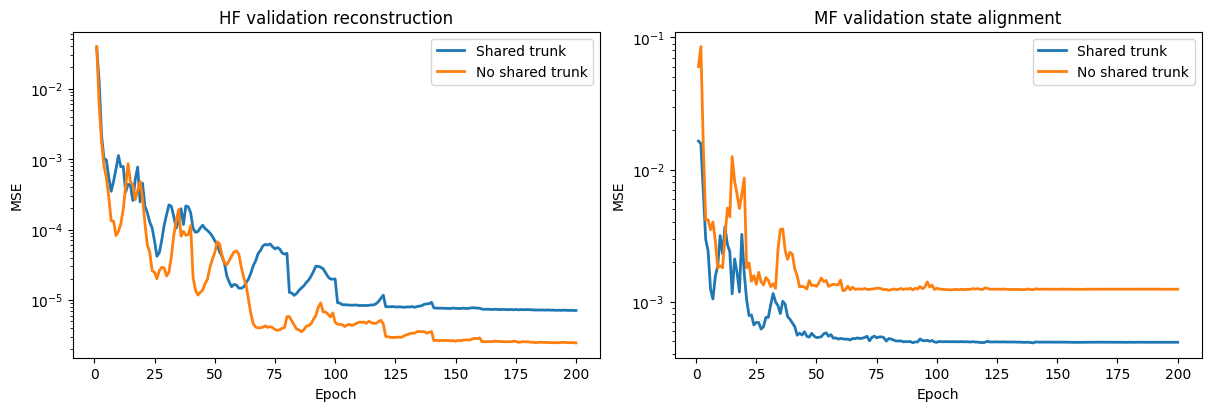

Shared trunk: parameters=169,602, val_hf/reconstruction=7.0951e-06, val_mf_state/state_alignment=4.9254e-04
No shared trunk: parameters=168,410, val_hf/reconstruction=2.4566e-06, val_mf_state/state_alignment=1.2413e-03


In [11]:
epochs_ablation = np.arange(1, ablation_epochs + 1)
fig, ax = plt.subplots(1, 2, figsize=(12, 4), constrained_layout=True)

for mode in sharing_modes:
    history = sharing_results[mode]["history"]
    label = SHARED_MODE_LABELS[mode]
    ax[0].plot(
        epochs_ablation,
        [row.get("val_hf/reconstruction", np.nan) for row in history],
        linewidth=2,
        label=label,
    )
    ax[1].plot(
        epochs_ablation,
        [row.get("val_mf_state/state_alignment", np.nan) for row in history],
        linewidth=2,
        label=label,
    )

ax[0].set_title("HF validation reconstruction")
ax[0].set_xlabel("Epoch")
ax[0].set_ylabel("MSE")
ax[0].set_yscale("log")
ax[0].legend()

ax[1].set_title("MF validation state alignment")
ax[1].set_xlabel("Epoch")
ax[1].set_ylabel("MSE")
ax[1].set_yscale("log")
ax[1].legend()

plt.show()

for mode in sharing_modes:
    history = sharing_results[mode]["history"]
    print(
        f"{SHARED_MODE_LABELS[mode]}: "
        f"parameters={sharing_results[mode]['num_parameters']:,}, "
        f"val_hf/reconstruction={final_metric(history, 'val_hf/reconstruction'):.4e}, "
        f"val_mf_state/state_alignment={final_metric(history, 'val_mf_state/state_alignment'):.4e}"
    )


### Extra LF Data Ablation

To assess whether additional LF-only data improves HF reconstruction, we keep the MF training set fixed and vary the number of extra LF-only trajectories. To isolate the data effect, we switch off the SINDy term in this ablation.


In [12]:
lf_count_results = {}
lf_counts = [0, 16, 32, 64, len(train_dataset.lf_samples)]

for count in lf_counts:
    subset_train_dataset = TrainingTrajectoryDataset(
        mf_samples=train_dataset.mf_samples,
        lf_samples=train_dataset.lf_samples[:count],
        hf_samples=[],
    )
    lf_count_results[count] = run_experiment(
        train_dataset=subset_train_dataset,
        val_dataset=val_dataset,
        shared_mode="shared",
        loss_weights_override={"sindy_residual": 0.0},
        num_epochs=ablation_epochs,
        seed=0,
    )

final_hf_errors = [
    final_metric(lf_count_results[count]["history"], "val_hf/reconstruction")
    for count in lf_counts
]


  0%|          | 1/200 [00:06<20:35,  6.21s/it]

Epoch    1/200: train_lf/loss=1.3084e-02 | train_hf/loss=4.0856e-02 | train_mf_state/loss=7.0762e-05 | train_mf_sindy/loss=1.4086e-07 | val_lf/loss=1.2541e-04 | val_hf/loss=3.7965e-02 | val_mf_state/loss=5.2449e-05 | val_mf_sindy/loss=1.6878e-07


  1%|          | 2/200 [00:10<16:39,  5.05s/it]

Epoch    2/200: train_lf/loss=1.3464e-04 | train_hf/loss=1.4442e-02 | train_mf_state/loss=1.2729e-04 | train_mf_sindy/loss=4.1469e-07 | val_lf/loss=2.0645e-04 | val_hf/loss=9.9231e-03 | val_mf_state/loss=2.1934e-05 | val_mf_sindy/loss=4.4272e-07


  2%|▏         | 3/200 [00:14<15:18,  4.66s/it]

...

Epoch  198/200: train_lf/loss=2.2045e-06 | train_hf/loss=4.2380e-07 | train_mf_state/loss=8.0248e-07 | train_mf_sindy/loss=7.2273e-08 | val_lf/loss=2.8348e-06 | val_hf/loss=5.5709e-06 | val_mf_state/loss=1.7886e-06 | val_mf_sindy/loss=1.3249e-07


100%|█████████▉| 199/200 [09:56<00:02,  2.86s/it]

Epoch  199/200: train_lf/loss=2.8669e-06 | train_hf/loss=4.2268e-07 | train_mf_state/loss=7.4332e-07 | train_mf_sindy/loss=7.2264e-08 | val_lf/loss=2.6403e-06 | val_hf/loss=5.5249e-06 | val_mf_state/loss=1.7011e-06 | val_mf_sindy/loss=1.3253e-07


100%|██████████| 200/200 [09:59<00:00,  3.00s/it]

Epoch  200/200: train_lf/loss=2.6439e-06 | train_hf/loss=4.1616e-07 | train_mf_state/loss=7.4459e-07 | train_mf_sindy/loss=7.2293e-08 | val_lf/loss=2.7333e-06 | val_hf/loss=5.5081e-06 | val_mf_state/loss=1.8406e-06 | val_mf_sindy/loss=1.3254e-07


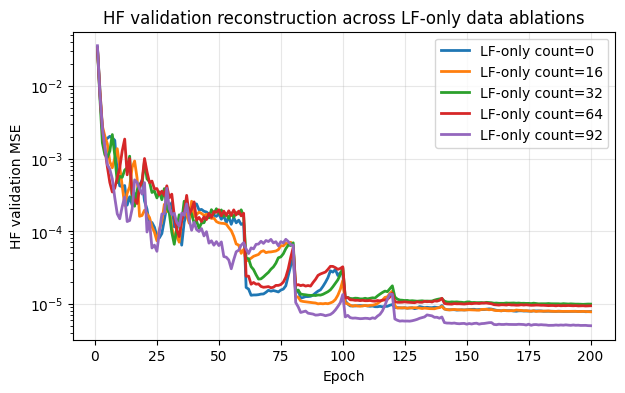

LF-only count= 0: val_hf/reconstruction=7.7976e-06
LF-only count=16: val_hf/reconstruction=7.7415e-06
LF-only count=32: val_hf/reconstruction=9.8736e-06
LF-only count=64: val_hf/reconstruction=9.3688e-06
LF-only count=92: val_hf/reconstruction=4.9750e-06


In [13]:
available_counts = [count for count in lf_counts if count in lf_count_results]
missing_counts = [count for count in lf_counts if count not in lf_count_results]

plt.figure(figsize=(7, 4))

for count in available_counts:
    history = lf_count_results[count]["history"]
    epochs = np.arange(1, len(history) + 1)
    val_hf_loss = [row.get("val_hf/reconstruction", np.nan) for row in history]

    plt.plot(
        epochs,
        val_hf_loss,
        linewidth=2,
        label=f"LF-only count={count}",
    )

plt.xlabel("Epoch")
plt.ylabel("HF validation MSE")
plt.title("HF validation reconstruction across LF-only data ablations")
plt.yscale("log")
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

if missing_counts:
    print(f"Missing results for counts: {missing_counts}")

for count in available_counts:
    history = lf_count_results[count]["history"]
    print(
        f"LF-only count={count:2d}: "
        f"val_hf/reconstruction={final_metric(history, 'val_hf/reconstruction'):.4e}"
    )


### SINDy Ablation

Finally, we compare the same training setup with and without the SINDy residual term. We inspect both the validation metrics and the resulting latent trajectories for one paired sample.


  0%|          | 1/200 [00:02<09:23,  2.83s/it]

Epoch    1/200: train_lf/loss=1.2748e-02 | train_hf/loss=3.9660e-02 | train_mf_state/loss=6.7950e-05 | train_mf_sindy/loss=4.4427e-07 | val_lf/loss=1.6569e-04 | val_hf/loss=3.9627e-02 | val_mf_state/loss=3.6196e-05 | val_mf_sindy/loss=5.1441e-07


  1%|          | 2/200 [00:05<08:51,  2.68s/it]

Epoch    2/200: train_lf/loss=1.6374e-04 | train_hf/loss=1.3275e-02 | train_mf_state/loss=9.1579e-05 | train_mf_sindy/loss=4.5943e-07 | val_lf/loss=3.3418e-04 | val_hf/loss=8.4693e-03 | val_mf_state/loss=1.2688e-04 | val_mf_sindy/loss=4.9624e-07


  2%|▏         | 3/200 [00:08<09:05,  2.77s/it]

...

Epoch  198/200: train_lf/loss=8.1009e-06 | train_hf/loss=7.7371e-07 | train_mf_state/loss=1.2528e-06 | train_mf_sindy/loss=5.8116e-08 | val_lf/loss=6.2787e-06 | val_hf/loss=1.2033e-05 | val_mf_state/loss=2.4517e-06 | val_mf_sindy/loss=9.1344e-08


100%|█████████▉| 199/200 [09:30<00:02,  2.62s/it]

Epoch  199/200: train_lf/loss=6.3823e-06 | train_hf/loss=7.7906e-07 | train_mf_state/loss=1.5112e-06 | train_mf_sindy/loss=5.8148e-08 | val_lf/loss=7.6788e-06 | val_hf/loss=1.2054e-05 | val_mf_state/loss=3.0009e-06 | val_mf_sindy/loss=9.1339e-08


100%|██████████| 200/200 [09:32<00:00,  2.86s/it]

Epoch  200/200: train_lf/loss=7.6894e-06 | train_hf/loss=7.6328e-07 | train_mf_state/loss=1.2440e-06 | train_mf_sindy/loss=5.8129e-08 | val_lf/loss=6.4738e-06 | val_hf/loss=1.1912e-05 | val_mf_state/loss=2.5817e-06 | val_mf_sindy/loss=9.1395e-08


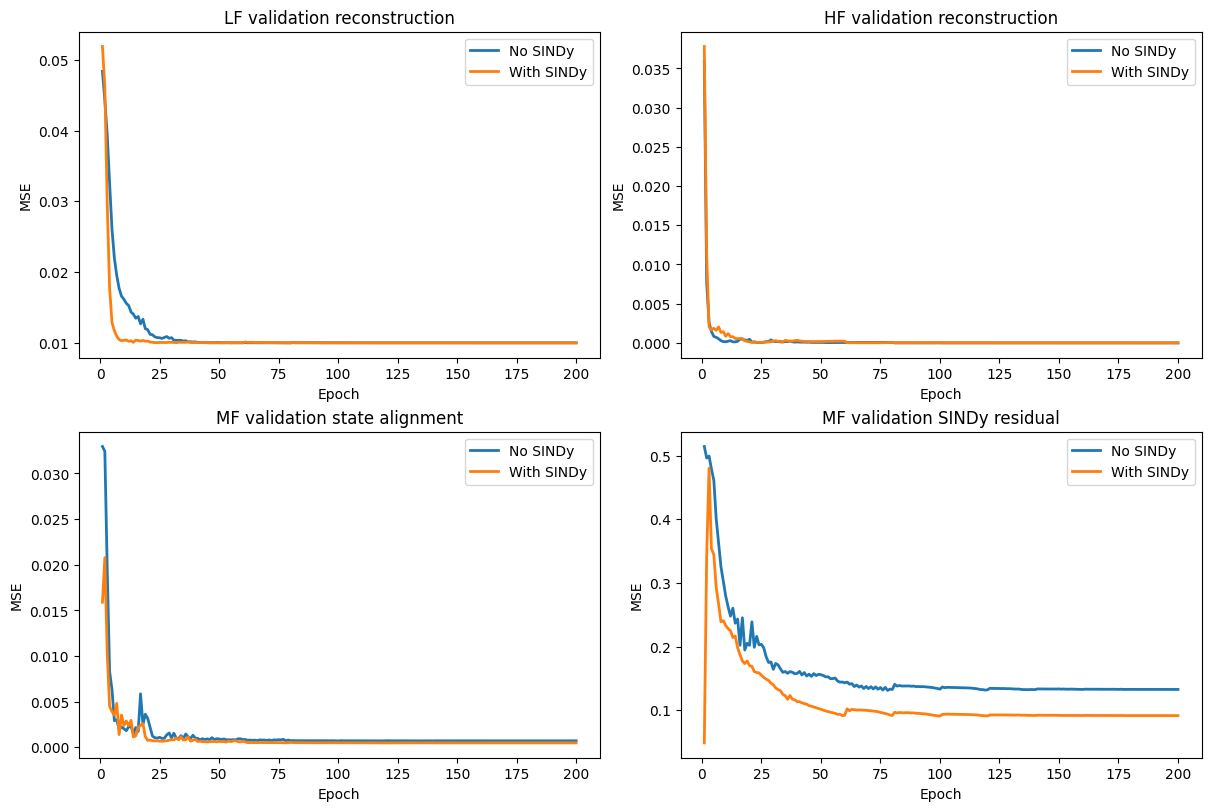

No SINDy: val_lf/reconstruction=9.9712e-03, val_hf/reconstruction=4.9750e-06, val_mf_state/state_alignment=7.1476e-04, val_mf_sindy/sindy_residual=1.3254e-01
With SINDy: val_lf/reconstruction=9.9612e-03, val_hf/reconstruction=1.0779e-05, val_mf_state/state_alignment=4.9014e-04, val_mf_sindy/sindy_residual=9.1395e-02


In [14]:
sindy_ablation_results = {}
sindy_configs = {
    "No SINDy": {"sindy_residual": 0.0},
    "With SINDy": None,
}

for label, weight_update in sindy_configs.items():
    sindy_ablation_results[label] = run_experiment(
        train_dataset=train_dataset,
        val_dataset=val_dataset,
        shared_mode="shared",
        loss_weights_override=weight_update,
        num_epochs=ablation_epochs,
        seed=0,
    )

fig, ax = plt.subplots(2, 2, figsize=(12, 8), constrained_layout=True)

metric_specs = [
    ("LF validation reconstruction", "val_lf/reconstruction"),
    ("HF validation reconstruction", "val_hf/reconstruction"),
    ("MF validation state alignment", "val_mf_state/state_alignment"),
    ("MF validation SINDy residual", "val_mf_sindy/sindy_residual"),
]

for axis, (title, key) in zip(ax.ravel(), metric_specs, strict=True):
    for label, result in sindy_ablation_results.items():
        history = result["history"]
        axis.plot(
            epochs_ablation,
            [row.get(key, np.nan) for row in history],
            linewidth=2,
            label=label,
        )

    axis.set_title(title)
    axis.set_xlabel("Epoch")
    axis.set_ylabel("MSE")
    axis.legend()

plt.show()

for label, result in sindy_ablation_results.items():
    history = result["history"]
    print(
        f"{label}: "
        f"val_lf/reconstruction={final_metric(history, 'val_lf/reconstruction'):.4e}, "
        f"val_hf/reconstruction={final_metric(history, 'val_hf/reconstruction'):.4e}, "
        f"val_mf_state/state_alignment={final_metric(history, 'val_mf_state/state_alignment'):.4e}, "
        f"val_mf_sindy/sindy_residual={final_metric(history, 'val_mf_sindy/sindy_residual'):.4e}"
    )


### Latent Trajectories With and Without SINDy

To understand the qualitative effect of the SINDy term, we compare the encoded LF and HF latent trajectories for the same paired validation sample, with and without the dynamics-aware regularization.


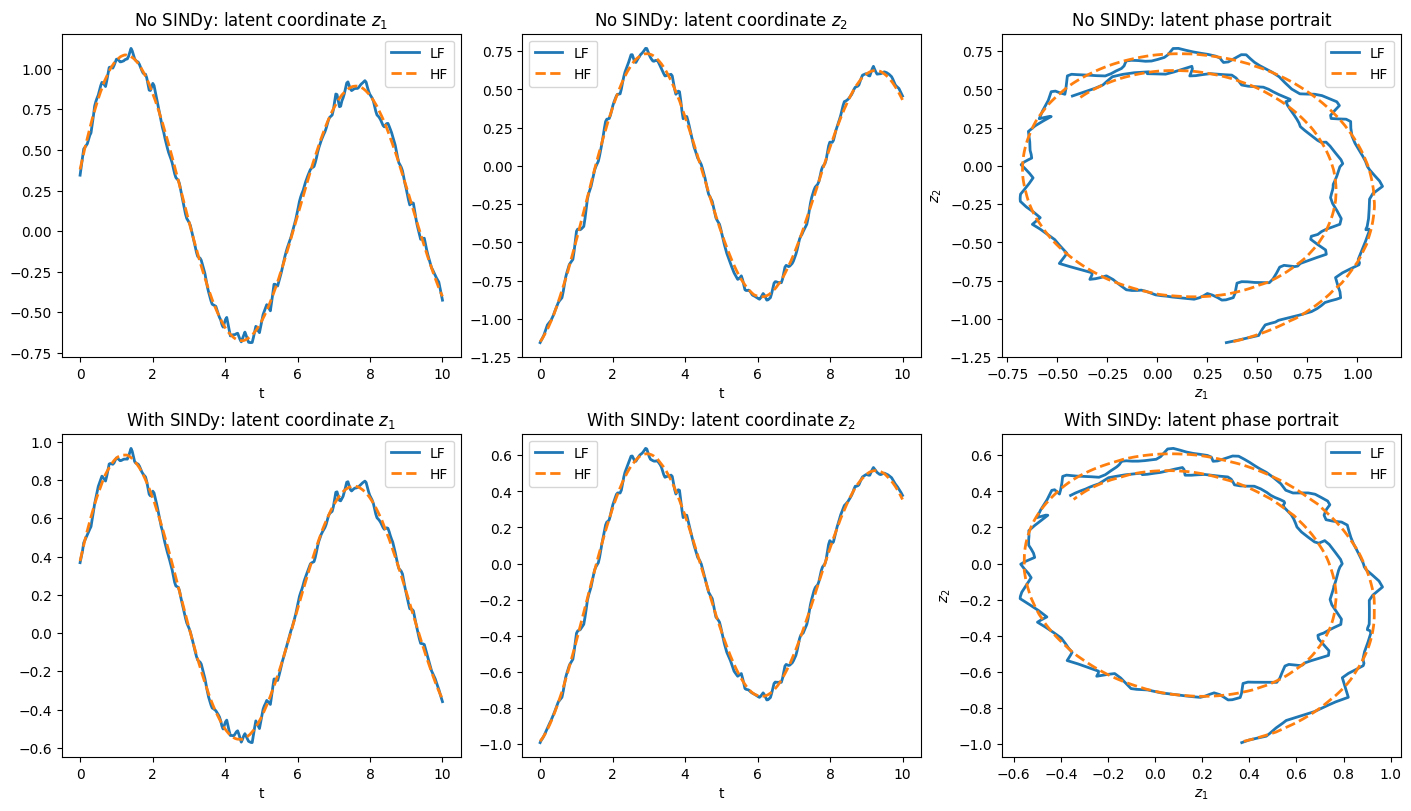

In [15]:
example_mf = (
    val_dataset.mf_samples[0]
    if len(val_dataset.mf_samples) > 0
    else train_dataset.mf_samples[0]
)
common_time = paired_common_time_grid(example_mf, target_steps=300)

lf_states = resample_state_sequence(
    example_mf.lf_trajectory.time,
    example_mf.lf_trajectory.states,
    common_time,
)
hf_states = resample_state_sequence(
    example_mf.hf_trajectory.time,
    example_mf.hf_trajectory.states,
    common_time,
)

lf_tensor = torch.as_tensor(lf_states, dtype=torch.float32, device=device)
hf_tensor = torch.as_tensor(hf_states, dtype=torch.float32, device=device)

fig, ax = plt.subplots(2, 3, figsize=(14, 8), constrained_layout=True)

for row, (label, result) in enumerate(sindy_ablation_results.items()):
    experiment_model = result["model"]
    experiment_model.eval()

    with torch.no_grad():
        z_lf = extract_shared_latent(
            experiment_model,
            experiment_model.encode(lf_tensor, "LF"),
        ).cpu().numpy()
        z_hf = extract_shared_latent(
            experiment_model,
            experiment_model.encode(hf_tensor, "HF"),
        ).cpu().numpy()

    ax[row, 0].plot(common_time, z_lf[:, 0], linewidth=2, label="LF")
    ax[row, 0].plot(common_time, z_hf[:, 0], linewidth=2, linestyle="--", label="HF")
    ax[row, 0].set_title(f"{label}: latent coordinate $z_1$")
    ax[row, 0].set_xlabel("t")
    ax[row, 0].legend()

    ax[row, 1].plot(common_time, z_lf[:, 1], linewidth=2, label="LF")
    ax[row, 1].plot(common_time, z_hf[:, 1], linewidth=2, linestyle="--", label="HF")
    ax[row, 1].set_title(f"{label}: latent coordinate $z_2$")
    ax[row, 1].set_xlabel("t")
    ax[row, 1].legend()

    ax[row, 2].plot(z_lf[:, 0], z_lf[:, 1], linewidth=2, label="LF")
    ax[row, 2].plot(z_hf[:, 0], z_hf[:, 1], linewidth=2, linestyle="--", label="HF")
    ax[row, 2].set_title(f"{label}: latent phase portrait")
    ax[row, 2].set_xlabel(r"$z_1$")
    ax[row, 2].set_ylabel(r"$z_2$")
    ax[row, 2].legend()

plt.show()
